In [3]:
# ======================= DECISION TREE MODEL + PCA WITH CROSS VALIDATION (SEPARATE TRAIN & TEST FILES) =======================
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.preprocessing import MinMaxScaler, label_binarize
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_score, recall_score, f1_score, roc_auc_score
)

# --- Load Data ---
train_data = pd.read_csv('/content/drive/MyDrive/Senior_Project/train_split.csv')
test_data  = pd.read_csv('/content/drive/MyDrive/Senior_Project/test_split.csv')

# --- Features & Target ---
features = ['PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES',
            'DEWP', 'RAIN', 'WSPM', 'wd_sin', 'wd_cos']

X_train = train_data[features].values
y_train = train_data['PM2.5_level'].values - 1
X_test  = test_data[features].values
y_test  = test_data['PM2.5_level'].values - 1

# --- Normalize Features ---
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# --- Apply PCA (keep 95% variance) ---
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

print(f"PCA reduced features from {X_train.shape[1]} to {X_train_pca.shape[1]} dimensions.\n")

# --- Cross-validation (Train Only) ---
kf = KFold(n_splits=10, shuffle=True, random_state=42)
accuracies, precisions, recalls, f1_scores, auc_scores = [], [], [], [], []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_pca), 1):
    X_fold_train, X_fold_val = X_train_pca[train_idx], X_train_pca[val_idx]
    y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]

    # --- Decision Tree ---
    model = DecisionTreeClassifier(random_state=42)
    model.fit(X_fold_train, y_fold_train)

    y_pred = model.predict(X_fold_val)
    y_pred_proba = model.predict_proba(X_fold_val)

    acc = accuracy_score(y_fold_val, y_pred)
    precision = precision_score(y_fold_val, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_fold_val, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_fold_val, y_pred, average='weighted', zero_division=0)

    y_bin = label_binarize(y_fold_val, classes=[0, 1, 2, 3, 4])
    auc = roc_auc_score(y_bin, y_pred_proba, average='macro', multi_class='ovo')

    accuracies.append(acc)
    precisions.append(precision)
    recalls.append(recall)
    f1_scores.append(f1)
    auc_scores.append(auc)

    print(f"Fold {fold}: Accuracy={acc:.3f}, Precision={precision:.3f}, Recall={recall:.3f}, "
          f"F1={f1:.3f}, AUC={auc:.3f}")

# --- Average Metrics ---
print("\nAverage metrics across 10 folds:")
print(f"Accuracy:  {np.mean(accuracies):.3f}")
print(f"Precision: {np.mean(precisions):.3f}")
print(f"Recall:    {np.mean(recalls):.3f}")
print(f"F1-score:  {np.mean(f1_scores):.3f}")
print(f"AUC-ROC:   {np.mean(auc_scores):.3f}")

# ===============================
# Final Model Training on Full Train Set
# ===============================
final_model = DecisionTreeClassifier(random_state=42)
final_model.fit(X_train_pca, y_train)

# --- Evaluate on Test set ---
y_pred_test = final_model.predict(X_test_pca)
y_pred_proba_test = final_model.predict_proba(X_test_pca)

y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3, 4])

test_accuracy = accuracy_score(y_test, y_pred_test)
test_precision = precision_score(y_test, y_pred_test, average='weighted', zero_division=0)
test_recall = recall_score(y_test, y_pred_test, average='weighted', zero_division=0)
test_f1 = f1_score(y_test, y_pred_test, average='weighted', zero_division=0)
test_auc = roc_auc_score(y_test_bin, y_pred_proba_test, average='macro', multi_class='ovo')

print("\nTest Set Results (Final Model):")
print(f"Accuracy:           {test_accuracy:.3f}")
print(f"Weighted Precision: {test_precision:.3f}")
print(f"Weighted Recall:    {test_recall:.3f}")
print(f"Weighted F1-score:  {test_f1:.3f}")
print(f"Macro AUC-ROC:      {test_auc:.3f}")

print("\nClassification Report:\n",
      classification_report(y_test, y_pred_test,
                            target_names=['Good', 'Moderate',
                                          'Unhealthy for Sensitive',
                                          'Unhealthy', 'Very Unhealthy'],
                            zero_division=0))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_test))


PCA reduced features from 12 to 6 dimensions.

Fold 1: Accuracy=0.597, Precision=0.598, Recall=0.597, F1=0.597, AUC=0.698
Fold 2: Accuracy=0.600, Precision=0.603, Recall=0.600, F1=0.601, AUC=0.696
Fold 3: Accuracy=0.603, Precision=0.603, Recall=0.603, F1=0.603, AUC=0.700
Fold 4: Accuracy=0.598, Precision=0.602, Recall=0.598, F1=0.600, AUC=0.698
Fold 5: Accuracy=0.599, Precision=0.603, Recall=0.599, F1=0.601, AUC=0.698
Fold 6: Accuracy=0.599, Precision=0.601, Recall=0.599, F1=0.600, AUC=0.698
Fold 7: Accuracy=0.597, Precision=0.600, Recall=0.597, F1=0.598, AUC=0.696
Fold 8: Accuracy=0.591, Precision=0.592, Recall=0.591, F1=0.592, AUC=0.694
Fold 9: Accuracy=0.595, Precision=0.598, Recall=0.595, F1=0.596, AUC=0.696
Fold 10: Accuracy=0.601, Precision=0.601, Recall=0.601, F1=0.601, AUC=0.698

Average metrics across 10 folds:
Accuracy:  0.598 ± 0.003
Precision: 0.600 ± 0.003
Recall:    0.598 ± 0.003
F1-score:  0.599 ± 0.003
AUC-ROC:   0.697 ± 0.002

Test Set Results (Final Model):
Accuracy: 

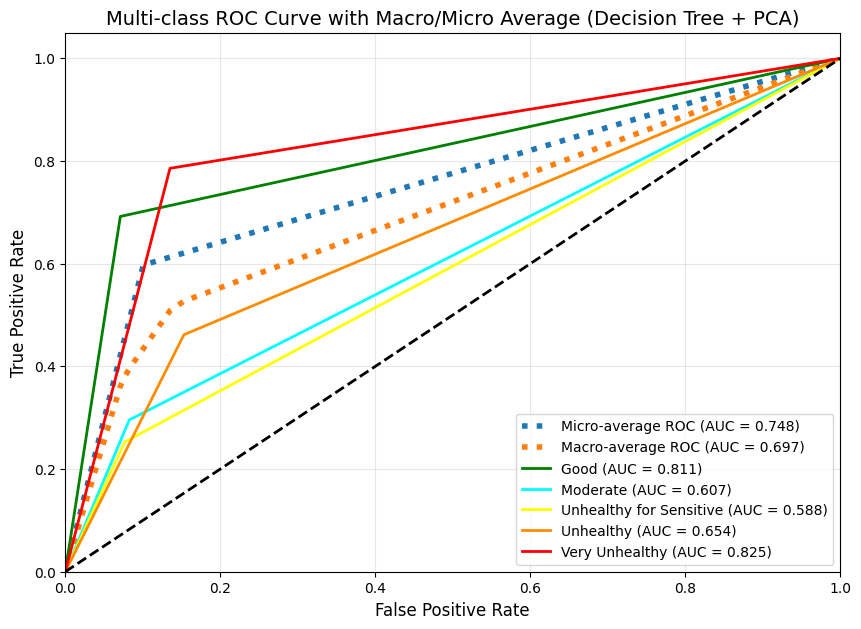

In [4]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from itertools import cycle

# ============================================
# Multi-class ROC Curve (Test Set)
# ============================================

n_classes = y_test_bin.shape[1]

# คำนวณ ROC curve และ AUC สำหรับแต่ละ class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba_test[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# คำนวณ micro-average ROC curve และ AUC
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_pred_proba_test.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# คำนวณ macro-average ROC curve และ AUC
# รวม FPR ทั้งหมดของทุก class แล้วทำ interpolation
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_classes
fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# ============================================
# Plot ROC Curves
# ============================================

plt.figure(figsize=(10, 7))
plt.plot(fpr["micro"], tpr["micro"],
         label=f'Micro-average ROC (AUC = {roc_auc["micro"]:.3f})',
         linestyle=':', linewidth=4)
plt.plot(fpr["macro"], tpr["macro"],
         label=f'Macro-average ROC (AUC = {roc_auc["macro"]:.3f})',
         linestyle=':', linewidth=4)

# Plot ROC ของแต่ละ class
colors = cycle(['green', 'aqua', 'yellow', 'darkorange', 'red'])
class_names = ['Good', 'Moderate', 'Unhealthy for Sensitive', 'Unhealthy', 'Very Unhealthy']

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'{class_names[i]} (AUC = {roc_auc[i]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Multi-class ROC Curve with Macro/Micro Average (Decision Tree + PCA)', fontsize=14)
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.show()
